In [ ]:
!pip install requests beautifulsoup4 pandas matplotlib seaborn nltk


**TASK 1:Web Scrapping**
1. Use Python libraries like BeautifulSoup or Scrapy to extract data from websites.
1. Identify and collect relevant datasets from public web pages.
1. If you don’t code, use automated tools like Octoparse or ParseHub.
1. Learn to handle HTML structure and web navigation to gather accurate data.
1. Create custom datasets tailored to specific analysis needs.

















In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# 1. Ask the website for its HTML data
url = "https://books.toscrape.com/"
response = requests.get(url)

# 2. Parse the HTML code so Python can understand it
soup = BeautifulSoup(response.text, "html.parser")

# 3. Create empty lists to store our data
titles = []
prices = []
ratings = []

# 4. Find all books on the page
books = soup.find_all("article", class_="product_pod")

for book in books:
    # Extract the title
    title = book.h3.a["title"]
    titles.append(title)

    # Extract the price text
    price_text = book.find("p", class_="price_color").text

    # FIXED: Clear out both '£' and 'Â' symbols to leave just the pure number string
    clean_price_text = price_text.replace("£", "").replace("Â", "").strip()
    clean_price = float(clean_price_text)
    prices.append(clean_price)

    # Extract the star rating text
    rating_class = book.find("p", class_="star-rating")["class"][1]
    ratings.append(rating_class)

# 5. Save the data into a structured table (DataFrame)
df = pd.DataFrame({"Title": titles, "Price": prices, "Star_Rating": ratings})
df.to_csv("sandbox_books.csv", index=False)

# Display the first few rows
print(df.head())


                                   Title  Price Star_Rating
0                   A Light in the Attic  51.77       Three
1                     Tipping the Velvet  53.74         One
2                             Soumission  50.10         One
3                          Sharp Objects  47.82        Four
4  Sapiens: A Brief History of Humankind  54.23        Five


**TASK 2:** Exploratory Data Analysis (EDA)
1. Ask meaningful questions about the dataset before analysis.
1. Explore the data structure, including variables and data types.
1. Identify trends, patterns and anomalies within the data.
1. Test hypotheses and validate assumptions using statistics and visualization.
1. Detect potential data issues or problems to address in further analysis.


**❓ 1. Meaningful Questions to Ask Before Analysis**

1. **Price Distribution:** What is the most common price range for these books? Are there extreme outliers (very cheap or very expensive books)?
1. **Rating Patterns:** Do higher-rated books cost more than lower-rated books?
1. **Title Length Impact:** Do books with longer titles have higher prices or better star ratings?
1. **Text Trends:** What are the most common words used in these book titles? Do they hint at specific popular genres?


In [ ]:
# 1. Check the data structure and data types
print("--- Data Info ---")
print(df.info())

# 2. Get a quick statistical summary of numbers
print("\n--- Descriptive Statistics ---")
print(df.describe())

# 3. Look for empty/missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        20 non-null     object 
 1   Price        20 non-null     float64
 2   Star_Rating  20 non-null     object 
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes
None

--- Descriptive Statistics ---
           Price
count  20.000000
mean   38.048500
std    15.135231
min    13.990000
25%    22.637500
50%    41.380000
75%    51.865000
max    57.250000

--- Missing Values ---
Title          0
Price          0
Star_Rating    0
dtype: int64


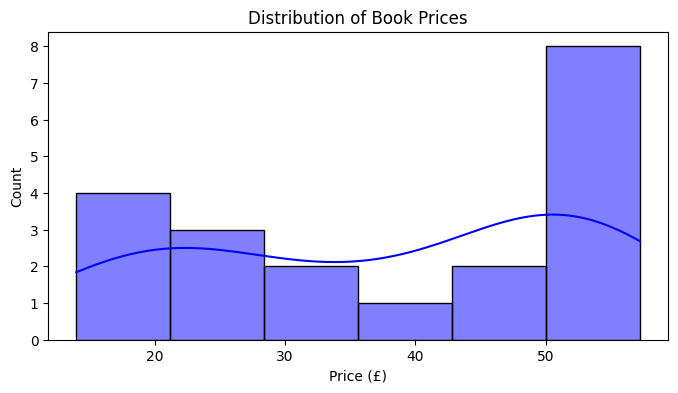

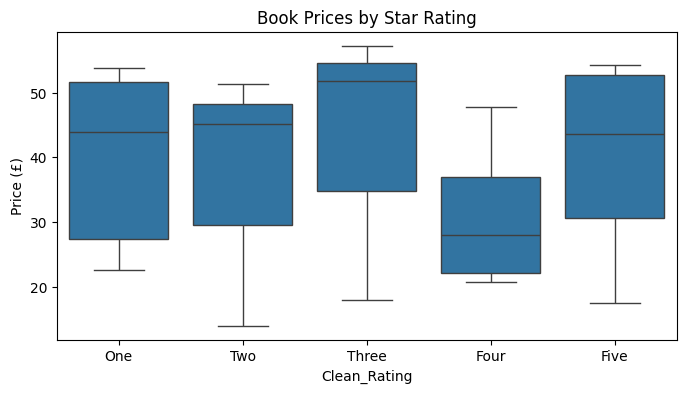

In [ ]:
#3. Identify Trends, Patterns, and Anomalies
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the Star_Rating column so it only contains the text rating
df['Clean_Rating'] = df['Star_Rating'].apply(lambda x: x[1] if isinstance(x, list) else x)

# Plot 1: See the spread of book prices
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Book Prices')
plt.xlabel('Price (£)')
plt.show()

# Plot 2: Compare Ratings vs Prices to find trends
plt.figure(figsize=(8, 4))
sns.boxplot(x='Clean_Rating', y='Price', data=df, order=['One', 'Two', 'Three', 'Four', 'Five'])
plt.title('Book Prices by Star Rating')
plt.ylabel('Price (£)')
plt.show()


Success! Your CSV file now includes Title Length.
Correlation between Title Length and Price: -0.13
Conclusion: Title length does not affect book prices.


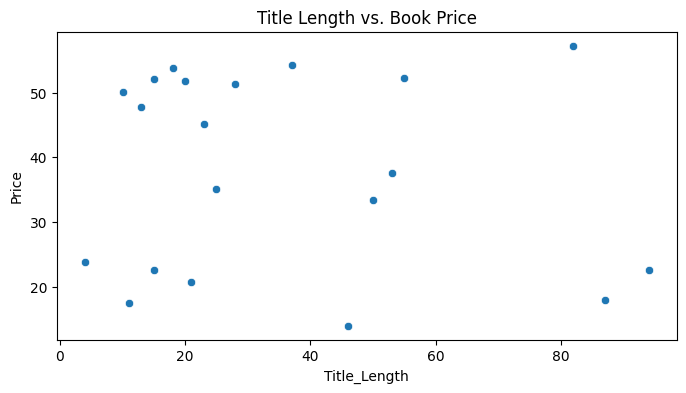

In [ ]:
# 4. Test Hypotheses and Validate Assumptions
# Create a new column for title length (number of characters)
df['Title_Length'] = df['Title'].apply(len)
df.to_csv('your_books_data.csv', index=False)
print("Success! Your CSV file now includes Title Length.")
# Calculate the correlation number between length and price
# (Closer to 1 means strong link, closer to 0 means no link)
correlation = df['Title_Length'].corr(df['Price'])
print(f"Correlation between Title Length and Price: {correlation:.2f}")
# 3. Use an IF statement to print the conclusion automatically
if -0.20 <= correlation <= 0.20:
    print("Conclusion: Title length does not affect book prices.")
elif correlation > 0.20:
    print("Conclusion: Longer titles tend to have higher book prices.")
else:
    print("Conclusion: Longer titles tend to have lower book prices.")

# Visualize the relationship
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Title_Length', y='Price', data=df)
plt.title('Title Length vs. Book Price')
plt.show()


In [ ]:
#5. Detect Potential Data Issues to Address Later
#Convert Text Ratings to Clean Numbers
# Create a dictionary to map words to numbers
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

# Create a new column with real numbers
df["Rating_Number"] = df["Star_Rating"].str.strip().map(rating_map)

# Calculate the true average rating
print(f"⭐ Average Star Rating: {df['Rating_Number'].mean():.2f} stars")


⭐ Average Star Rating: 2.85 stars


## For TASK 4 :Sentiment Analysis this data doesnt have review data so took new data and added a column

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon (a dictionary of positive/negative words)
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Let's add some simulated user reviews to our dataset for learning
df['Review'] = [
    "I absolutely loved this book! It changed my life.",
    "Worst book ever. A complete waste of my money.",
    "It was okay, but a bit slow in the middle.",
    "Amazing read! Highly recommend to everyone.",
    "Terrible writing and boring characters.",
    "An average book, nothing special about it.",
    "Beautifully written story, I cried at the end.",
    "I hated it. Dropped it after two chapters.",
    "Decent book for a weekend read.",
    "Fantastic! Easily my favorite book of the year."
] * 2  # Repeating to fill all 20 rows of our scraped data

# Run sentiment analysis on each review
df['Sentiment_Score'] = df['Review'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Classify into labels based on the score
def get_label(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df['Sentiment_Label'] = df['Sentiment_Score'].apply(get_label)
print(df[['Review', 'Sentiment_Label']].head())


                                              Review Sentiment_Label
0  I absolutely loved this book! It changed my life.        Positive
1     Worst book ever. A complete waste of my money.        Negative
2         It was okay, but a bit slow in the middle.        Positive
3        Amazing read! Highly recommend to everyone.        Positive
4            Terrible writing and boring characters.        Negative


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
